cnn-bilst-mattention

In [1]:
import os
from glob import glob
import numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import backend as K
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
import random 

2025-09-04 23:35:24.991348: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757028925.182459      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757028925.245396      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


prepare data

In [4]:
import pandas as pd

def load_split_data_from_excel(excel_path):
    
    try:
        df_train = pd.read_excel(excel_path, sheet_name='data_train')
        df_test = pd.read_excel(excel_path, sheet_name='data_test')

        data_train_paths = df_train['filepath'].tolist()
        data_test_paths = df_test['filepath'].tolist()
        
        print(f"Load {len(data_train_paths)} path file train.")
        print(f"Load {len(data_test_paths)} path file test.")
        
        return data_train_paths, data_test_paths

    except FileNotFoundError:
        print(f"Error file not found '{excel_path}'")
        return None, None
    except Exception as e:
        print(f"Error read file: {e}")
        return None, None


In [5]:
# Attention Layer
class Attention(layers.Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1),
                                 initializer="normal", trainable=True)
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1),
                                 initializer="zeros", trainable=True)
        super(Attention, self).build(input_shape)

    def call(self, x):
        # e = tanh(Wx + b)
        e = K.tanh(K.dot(x, self.W) + self.b)
        # a = softmax(e)
        a = K.softmax(e, axis=1)
        # output = a * x
        output = x * a
        return K.sum(output, axis=1)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

In [10]:

EMOTIONS = ['Angry', 'Happy', 'Fear', 'Neutral', 'Sad', 'Boredom', 'Disgust']
NUM_CLASSES = len(EMOTIONS)
# Check label distribution
emotion_map = {
    'Angry': 0,
    'Happy': 1,
    'Fear': 2,
    'Neutral': 3,
    'Sad': 4,
    'Boredom': 5, 
    'Disgust': 6
}

# Actual calculation needed from the data
GLOBAL_MEAN_PITCH = 0.0
GLOBAL_JITTER = 0.0
GLOBAL_PITCH_SLOPE = 0.0

# Function to add noise
def add_noise(audio, noise_factor=0.01):
    noise = np.random.randn(len(audio))
    return audio + noise_factor * noise

# Function to change pitch
def pitch_shift(audio, sr, n_steps=2): # Random n_steps
    return librosa.effects.pitch_shift(audio, sr=sr, n_steps=n_steps)

# Function to apply time stretching
def time_stretch(audio, rate=0.95): # Random rate
    return librosa.effects.time_stretch(audio, rate=rate)

# Function to apply time shifting
def time_shift(audio, shift_max=0.2, sr=16000):
    shift = int(np.random.uniform(-shift_max, shift_max) * sr)
    return np.roll(audio, shift)

# Function to normalize pitch
def normalize_pitch(pitches):
    pitches = pitches[pitches > 0]
    if len(pitches) == 0:
        return GLOBAL_MEAN_PITCH, GLOBAL_JITTER, GLOBAL_PITCH_SLOPE
    
    mean_pitch = np.mean(pitches)
    normalized_pitches = pitches - mean_pitch
    jitter = np.std(normalized_pitches) if len(normalized_pitches) > 0 else 0
    
    # Check if there are enough points for polyfit
    if len(pitches) > 1:
        slope = np.polyfit(np.arange(len(pitches)), pitches, 1)[0]
    else:
        slope = 0 # Fallback for single point
    
    # Handle NaN values that might arise from edge cases
    if np.isnan(mean_pitch): mean_pitch = GLOBAL_MEAN_PITCH
    if np.isnan(jitter): jitter = GLOBAL_JITTER
    if np.isnan(slope): slope = GLOBAL_PITCH_SLOPE
    
    return mean_pitch, jitter, slope

# Feature extraction
def extract_features(audio_path, sample_rate=16000, duration=8, n_mfcc=26, n_frames=157, augment_type='normal', global_pitch_params=None):
    try:
        audio, sr = librosa.load(audio_path, sr=sample_rate)
        target_length = sample_rate * duration

        if len(audio) < target_length:
            audio = np.pad(audio, (0, target_length - len(audio)), mode='constant')
        else:
            audio = audio[:target_length]

        if augment_type == 'noise':
            audio = add_noise(audio)
        elif augment_type == 'pitch':
            audio = pitch_shift(audio, sr)
        elif augment_type == 'stretch':
            audio = time_stretch(audio)
        elif augment_type == 'shift':
            audio = time_shift(audio)

        hop_length = target_length // (n_frames - 1)

        # MFCCs + Delta + Delta-Delta
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length, n_fft=2048)
        mfcc_delta = librosa.feature.delta(mfcc)
        mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
        mfcc_features = np.concatenate((mfcc, mfcc_delta, mfcc_delta2), axis=0)
        
        # Pad or truncate MFCCs
        if mfcc_features.shape[1] > n_frames:
            mfcc_features = mfcc_features[:, :n_frames]
        elif mfcc_features.shape[1] < n_frames:
            mfcc_features = np.pad(mfcc_features, ((0, 0), (0, n_frames - mfcc_features.shape[1])), mode='constant')

        # Pitch features
        pitches, magnitudes = librosa.piptrack(y=audio, sr=sr, hop_length=hop_length)
        if global_pitch_params:
            mean_pitch, jitter, pitch_slope = normalize_pitch(pitches)
            # If normalize_pitch returns fallback values (0,0,0), use global defaults
            if mean_pitch == 0 and jitter == 0 and pitch_slope == 0:
                mean_pitch, jitter, pitch_slope = global_pitch_params
        else:
            mean_pitch, jitter, pitch_slope = normalize_pitch(pitches) # Will use current GLOBAL_*

        pitch_features_single = np.array([mean_pitch, jitter, pitch_slope])
        pitch_features = np.tile(pitch_features_single, (n_frames, 1)).T # Tile to match n_frames

        # Energy features (RMS + mean and std)
        energy = librosa.feature.rms(y=audio, hop_length=hop_length)[0]
        if len(energy) > n_frames:
            energy = energy[:n_frames]
        elif len(energy) < n_frames:
            energy = np.pad(energy, (0, n_frames - len(energy)), mode='constant')
        
        mean_energy = np.mean(energy)
        shimmer = np.std(energy) if len(energy) > 0 else 0
        energy_features = np.array([energy, np.full(n_frames, mean_energy), np.full(n_frames, shimmer)])

        # Zero-Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(y=audio, hop_length=hop_length)[0]
        if len(zcr) > n_frames:
            zcr = zcr[:n_frames]
        elif len(zcr) < n_frames:
            zcr = np.pad(zcr, (0, n_frames - len(zcr)), mode='constant')
        zcr_features = zcr[np.newaxis, :]

        # Chroma features
        chroma = librosa.feature.chroma_stft(y=audio, sr=sr, hop_length=hop_length, n_chroma=12)
        if chroma.shape[1] > n_frames:
            chroma = chroma[:, :n_frames]
        elif chroma.shape[1] < n_frames:
            chroma = np.pad(chroma, ((0, 0), (0, n_frames - chroma.shape[1])), mode='constant')

        # Spectral features
        spectral_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr, hop_length=hop_length)[0]
        spectral_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr, hop_length=hop_length)[0]
        spectral_contrast = librosa.feature.spectral_contrast(y=audio, sr=sr, hop_length=hop_length, n_bands=5)
        
        # Pad or truncate spectral features
        # Assuming all spectral features have the same number of frames
        if spectral_centroid.shape[0] > n_frames:
            spectral_centroid = spectral_centroid[:n_frames]
            spectral_rolloff = spectral_rolloff[:n_frames]
            spectral_contrast = spectral_contrast[:, :n_frames]
        elif spectral_centroid.shape[0] < n_frames:
            spectral_centroid = np.pad(spectral_centroid, (0, n_frames - spectral_centroid.shape[0]), mode='constant')
            spectral_rolloff = np.pad(spectral_rolloff, (0, n_frames - spectral_rolloff.shape[0]), mode='constant')
            spectral_contrast = np.pad(spectral_contrast, ((0, 0), (0, n_frames - spectral_contrast.shape[1])), mode='constant')
        spectral_features = np.vstack([spectral_centroid, spectral_rolloff, spectral_contrast])

        # Temporal features
        voiced_frames = librosa.effects.split(audio, top_db=20)
        speech_rate = len(voiced_frames) / (duration if duration > 0 else 1)
        pauses = len(voiced_frames) - 1 if len(voiced_frames) > 1 else 0
        temporal_features_single = np.array([speech_rate, pauses])
        temporal_features = np.tile(temporal_features_single, (n_frames, 1)).T

        features = np.concatenate([
            mfcc_features, # Now includes delta and delta-delta
            pitch_features,
            energy_features,
            zcr_features,
            chroma,
            spectral_features,
            temporal_features
        ], axis=0)

        return np.expand_dims(features, axis=-1)

    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None




# CNN + Attention model
def build_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same',
               kernel_regularizer=l2(0.001))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same',
               kernel_regularizer=l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same',
               kernel_regularizer=l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.3)(x)

    # Shape: (batch_size, time_steps, features)
    x = layers.Reshape((x.shape[1] * x.shape[2], x.shape[3]))(x)

    # Optional: add BiLSTM for temporal modeling
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)

    # Attention mechanism
    x = Attention()(x)

    # Classification
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model

# Build CNN improve
def build_cnn_2d(input_shape=(55, 157, 1)):
    model =  build_model(input_shape, num_classes=NUM_CLASSES)
    model.summary()
    return model

# Add a function to calculate GLOBAL_PITCH_PARAMS
def calculate_global_pitch_params(audio_files, sample_rate=16000):
    all_pitches = []
    for audio_path in audio_files:
        try:
            audio, sr = librosa.load(audio_path, sr=sample_rate)
            pitches, magnitudes = librosa.piptrack(y=audio, sr=sr)
            pitches = pitches[pitches > 0]
            if len(pitches) > 0:
                all_pitches.extend(pitches)
        except Exception as e:
            print(f"Error calculating global pitch for {audio_path}: {e}")
            continue
            
    if len(all_pitches) == 0:
        print("Warning: No valid pitches found to calculate global parameters. Using default zeros.")
        return 0.0, 0.0, 0.0

    all_pitches = np.array(all_pitches)
    global_mean_pitch = np.mean(all_pitches)
    
    normalized_all_pitches = all_pitches - global_mean_pitch
    global_jitter = np.std(normalized_all_pitches) if len(normalized_all_pitches) > 0 else 0
    
    # Calculate global pitch slope (simple average of local slopes, or fit a line to all pitches)
    # For simplicity, let's use the average of slopes calculated over reasonable segments
    # A more robust approach might involve fitting a trend line to all valid pitch values,
    # but that's computationally intensive. For global, a simple average might suffice or set to 0.
    global_pitch_slope = 0.0 # Often jitter is more informative than overall slope for global
    
    # Consider replacing NaN/inf with 0 in case of edge issues
    global_mean_pitch = 0.0 if np.isnan(global_mean_pitch) or np.isinf(global_mean_pitch) else global_mean_pitch
    global_jitter = 0.0 if np.isnan(global_jitter) or np.isinf(global_jitter) else global_jitter
    global_pitch_slope = 0.0 if np.isnan(global_pitch_slope) or np.isinf(global_pitch_slope) else global_pitch_slope

    return global_mean_pitch, global_jitter, global_pitch_slope

# Function to prepare data with label mapping from directory
def prepare_training_data(audio_files, emotion_map, global_pitch_params):
    X, y = [], []
    augment_types = ['normal', 'noise', 'pitch', 'stretch', 'shift']
    skipped_files = 0
    processed_files = 0

    print(f"Total number of audio files: {len(audio_files)}")
    for audio_path in audio_files:
        folder_name = os.path.basename(os.path.dirname(audio_path))
        if folder_name not in emotion_map:
            skipped_files += 1
            continue
        emotion_idx = emotion_map[folder_name]

        for aug_type in augment_types:
            features = extract_features(str(audio_path), augment_type=aug_type, global_pitch_params=global_pitch_params)
            if features is None or np.all(features == 0):
                continue
            X.append(features)
            y.append(emotion_idx)
            processed_files += 1

    print(f"Processed: {processed_files} samples, skipped: {skipped_files} file.")
    if not X or not y:
        raise ValueError("No audio files were successfully processed. Please check the data path or emotion_map.")

    X = np.array(X)
    y = to_categorical(y, num_classes=NUM_CLASSES)
    print(f"Dataset shape: X={X.shape}, y={y.shape}")
    return X, y

# Function to prepare test data
def prepare_test_data(audio_files, emotion_map, global_pitch_params):
    X, y = [], []
    skipped_files = 0
    processed_files = 0

    print(f"Total number of test audio files: {len(audio_files)}")
    for audio_path in audio_files:
        folder_name = os.path.basename(os.path.dirname(audio_path))
        if folder_name not in emotion_map:
            skipped_files += 1
            continue
        emotion_idx = emotion_map[folder_name]
        features = extract_features(str(audio_path), augment_type='normal', global_pitch_params=global_pitch_params)
        if features is None or np.all(features == 0):
            continue
        X.append(features)
        y.append(emotion_idx)
        processed_files += 1

    print(f"Processed: {processed_files} samples, skipped: {skipped_files} files.")
    if not X or not y:
        raise ValueError("No test audio files were successfully processed.")

    X = np.array(X)
    y = to_categorical(y, num_classes=NUM_CLASSES)
    print(f"Test dataset shape: X={X.shape}, y={y.shape}")
    return X, y


# Evaluate the model using confusion matrix and F1 Score
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)

    # Print sample probabilities for debugging
    print("\nSample prediction probabilities:")
    for i in range(min(5, len(X_test))):
        print(f"Sample {i+1}: True={EMOTIONS[y_true_classes[i]]}, Pred={EMOTIONS[y_pred_classes[i]]}, Prob={y_pred[i]}")

    cm = confusion_matrix(y_true_classes, y_pred_classes)
    plt.figure(figsize=(10, 8))
    sns_heatmap  = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=EMOTIONS, yticklabels=EMOTIONS)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true_classes, y_pred_classes, target_names=EMOTIONS))

    print("\nEvaluation metric formulas:")
    print("1. Precision = TP / (TP + FP)")
    print("   - TP (True Positives): Number of samples correctly predicted for a class.")
    print("   - FP (False Positives): Number of samples incorrectly predicted as that class.")
    print("2. Recall = TP / (TP + FN)")
    print("   - FN (False Negatives): Number of samples that belong to the class but were incorrectly predicted.")
    print("3. F1 Score = 2 * (Precision * Recall) / (Precision + Recall)")

# Train and evaluate
def train_and_evaluate_model(model, X, y, epochs=200, batch_size=16, checkpoint_path='best_model.h5', class_weight=None):
    if len(X) == 0 or len(y) == 0:
        raise ValueError("Training dataset is empty. Please check the input data.")

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}")

    #model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    #              loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    #              metrics=['accuracy'])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=0.00001)
    checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, mode='min', verbose=1)

    history = model.fit(X_train, y_train,
                        validation_data=(X_val, y_val),
                        epochs=epochs,
                        batch_size=batch_size,
                        callbacks=[early_stopping, reduce_lr, checkpoint],
                        class_weight=class_weight,
                        verbose=1)

    val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
    print(f"\nEvaluation on the test set:")
    print(f" - Loss: {val_loss:.4f}")
    print(f" - Accuracy: {val_accuracy:.4f}")
    return model, history, X_val, y_val

# Direct prediction using CNN
def predict_emotion(audio_path, model, scaler, global_pitch_params):
    features = extract_features(audio_path, augment_type='normal', global_pitch_params=global_pitch_params)
    if features is None or np.all(features == 0):
        return "Prediction failed: Feature extraction error."
        
    # Reshape features for scaling
    features_2d = features.reshape(1, -1)
    features_2d = scaler.transform(features_2d)  # Apply scaler
    features = features_2d.reshape(features.shape)
    
    features = np.expand_dims(features, axis=0)
    prediction = model.predict(features, verbose=0)
    predicted_emotion_idx = np.argmax(prediction, axis=1)[0]
    
    # Print probabilities for debugging
    print(f"Prediction probabilities for {audio_path}: {prediction[0]}")
    return EMOTIONS[predicted_emotion_idx]

# Plot Loss Chart
def plot_loss_history(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

Load 474 path file train.
Load 61 path file test.
Total train files: 474
Total test files: 61
Calculating GLOBAL_PITCH_PARAMS from training data...
GLOBAL_MEAN_PITCH: 1688.6304, GLOBAL_JITTER: 1159.1036, GLOBAL_PITCH_SLOPE: 0.0000
Original label distribution: Counter({'Angry': 108, 'Boredom': 73, 'Neutral': 70, 'Happy': 63, 'Fear': 62, 'Sad': 57, 'Disgust': 41})
Class weights: {0: 0.626984126984127, 1: 1.0748299319727892, 2: 1.0921658986175116, 3: 0.9673469387755103, 4: 1.1879699248120301, 5: 0.9275929549902152, 6: 1.651567944250871}
Total number of audio files: 474
Processed: 2370 samples, skipped: 0 file.
Dataset shape: X=(2370, 107, 157, 1), y=(2370, 7)
X shape: (2370, 107, 157, 1)
Calculated CNN Input Shape: (107, 157, 1)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 107, 157, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 107, 157, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 107, 157, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 53, 78, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 53, 78, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 53, 78, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 53, 78, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 26, 39, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 26, 39, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 26, 39, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 26, 39, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 13, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 13, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 247, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 247, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_1 (Attention)         │ (None, 128)            │           375 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,470 (786.99 KB)

 Trainable params: 201,022 (785.24 KB)

 Non-trainable params: 448 (1.75 KB)

Train shape: (1896, 107, 157, 1), Val shape: (474, 107, 157, 1)
Epoch 1/100


E0000 00:00:1757029744.162568      36 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/dropout_4_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2001 - loss: 2.0449
Epoch 1: val_loss improved from inf to 2.32178, saving model to best_cnn_bilstm_vesc.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.2005 - loss: 2.0443 - val_accuracy: 0.2110 - val_loss: 2.3218 - learning_rate: 0.0010
Epoch 2/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3630 - loss: 1.6807
Epoch 2: val_loss improved from 2.32178 to 1.93060, saving model to best_cnn_bilstm_vesc.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.3631 - loss: 1.6803 - val_accuracy: 0.2215 - val_loss: 1.9306 - learning_rate: 0.0010
Epoch 3/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4308 - loss: 1.4859
Epoch 3: val_loss improved from 1.93060 to 1.56027, saving model to best_cnn_bilstm_vesc.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.4309 - loss: 1.4857 - val_accuracy: 0.3776 - val_loss: 1.5603 - learning_rate: 0.0010
Epoch 4/100
119/119 ━━━━━━━━━━━━━━━━━━━━

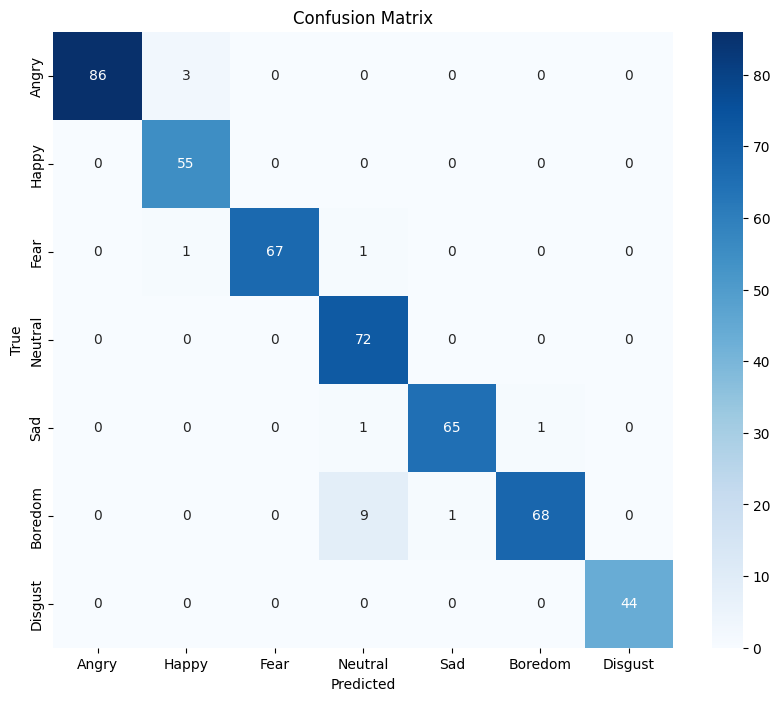


Classification Report:
              precision    recall  f1-score   support

       Angry       1.00      0.97      0.98        89
       Happy       0.93      1.00      0.96        55
        Fear       1.00      0.97      0.99        69
     Neutral       0.87      1.00      0.93        72
         Sad       0.98      0.97      0.98        67
     Boredom       0.99      0.87      0.93        78
     Disgust       1.00      1.00      1.00        44

    accuracy                           0.96       474
   macro avg       0.97      0.97      0.97       474
weighted avg       0.97      0.96      0.96       474


Evaluation metric formulas:
1. Precision = TP / (TP + FP)
   - TP (True Positives): Number of samples correctly predicted for a class.
   - FP (False Positives): Number of samples incorrectly predicted as that class.
2. Recall = TP / (TP + FN)
   - FN (False Negatives): Number of samples that belong to the class but were incorrectly predicted.
3. F1 Score = 2 * (Precision * R

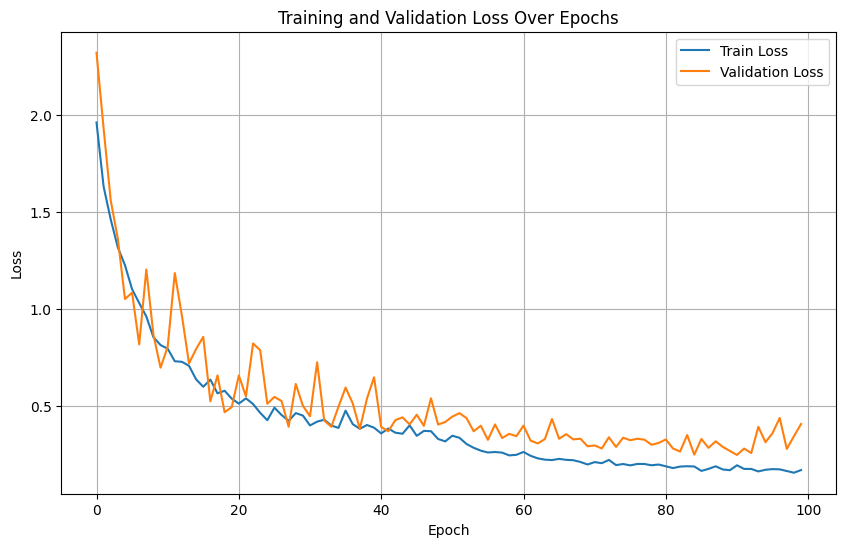

In [11]:
if __name__ == "__main__":
    PATH_DATA_TRAIN = '/kaggle/input/speech-emotion-10/data_EmoDB_split.xlsx'
    # Path to the data
    files_train, files_test = load_split_data_from_excel(excel_path = PATH_DATA_TRAIN)
    # Calculate GLOBAL_PITCH_PARAMS first
    print(f"Total train files: {len(files_train)}")
    print(f"Total test files: {len(files_test)}")
    print("Calculating GLOBAL_PITCH_PARAMS from training data...")
    GLOBAL_MEAN_PITCH, GLOBAL_JITTER, GLOBAL_PITCH_SLOPE = calculate_global_pitch_params(files_train)
    print(f"GLOBAL_MEAN_PITCH: {GLOBAL_MEAN_PITCH:.4f}, GLOBAL_JITTER: {GLOBAL_JITTER:.4f}, GLOBAL_PITCH_SLOPE: {GLOBAL_PITCH_SLOPE:.4f}")
    

    y_raw = [emotion_map.get(os.path.basename(os.path.dirname(f)), -1) for f in files_train]
    print("Original label distribution:", Counter([EMOTIONS[i] for i in y_raw if i != -1]))

    # Calculate class weights
    y_raw_train = [y for y in y_raw if y != -1]
    class_weights = compute_class_weight('balanced', classes=np.unique(y_raw_train), y=y_raw_train)
    class_weight_dict = dict(enumerate(class_weights))
    print("Class weights:", class_weight_dict)

    # Prepare data
    X, y = prepare_training_data(files_train, emotion_map, (GLOBAL_MEAN_PITCH, GLOBAL_JITTER, GLOBAL_PITCH_SLOPE))
    print(f"X shape: {X.shape}")

    # Normalize features
    scaler = StandardScaler()
    X_2d = X.reshape(X.shape[0], -1)
    X_2d = scaler.fit_transform(X_2d)
    X = X_2d.reshape(X.shape)

    calculated_input_dim0 = X.shape[1] 
    cnn_input_shape = (calculated_input_dim0, X.shape[2], 1)
    print(f"Calculated CNN Input Shape: {cnn_input_shape}")

    # Build and train the model
    cnn_model = build_cnn_2d(input_shape = cnn_input_shape)
    cnn_model, history, X_test, y_test = train_and_evaluate_model(
        cnn_model, X, y,
        epochs=100,
        batch_size=16,
        checkpoint_path='best_cnn_bilstm_vesc.keras',
        class_weight=class_weight_dict
    )

    # Save the final model
    cnn_model.save('final_cnn_bilstm_vesc.keras')
    evaluate_model(cnn_model, X_test, y_test)
    plot_loss_history(history)

Test-part

Total test files: 61
Original label distribution (test): Counter({'Angry': 19, 'Neutral': 9, 'Boredom': 8, 'Happy': 8, 'Fear': 7, 'Sad': 5, 'Disgust': 5})
GLOBAL_MEAN_PITCH: 1688.6304, GLOBAL_JITTER: 1159.1036, GLOBAL_PITCH_SLOPE: 0.0000
Total number of test audio files: 61
Processed: 61 samples, skipped: 0 files.
Test dataset shape: X=(61, 107, 157, 1), y=(61, 7)

Sample prediction probabilities:
Sample 1: True=Fear, Pred=Fear, Prob=[5.3639083e-11 3.4243774e-07 9.9999952e-01 1.5379146e-07 2.3363839e-10
 3.1654620e-12 1.2645101e-09]
Sample 2: True=Fear, Pred=Fear, Prob=[5.1170307e-08 4.3339925e-04 6.5620923e-01 3.4333605e-01 5.6776598e-06
 1.5358790e-05 2.2774881e-07]
Sample 3: True=Fear, Pred=Fear, Prob=[5.9926563e-08 2.3277040e-05 9.9901438e-01 9.6216024e-04 4.6354934e-08
 7.3559909e-09 1.9492411e-08]
Sample 4: True=Fear, Pred=Fear, Prob=[7.16692000e-07 9.67088727e-06 9.99989510e-01 2.86945951e-08
 4.53216664e-09 1.23696045e-11 1.04587166e-07]
Sample 5: True=Fear, Pred=Fear, Prob=[1.

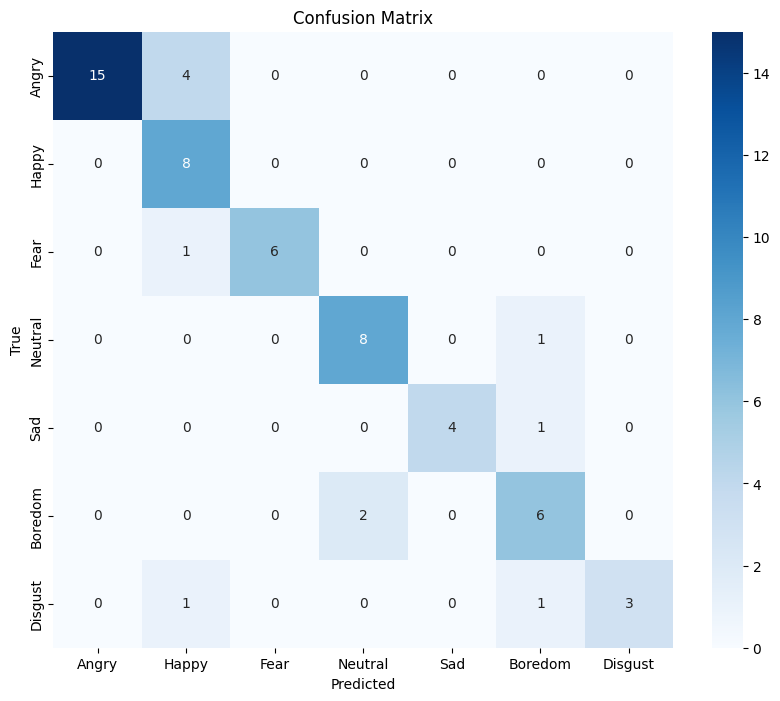


Classification Report:
              precision    recall  f1-score   support

       Angry       1.00      0.79      0.88        19
       Happy       0.57      1.00      0.73         8
        Fear       1.00      0.86      0.92         7
     Neutral       0.80      0.89      0.84         9
         Sad       1.00      0.80      0.89         5
     Boredom       0.67      0.75      0.71         8
     Disgust       1.00      0.60      0.75         5

    accuracy                           0.82        61
   macro avg       0.86      0.81      0.82        61
weighted avg       0.87      0.82      0.83        61


Evaluation metric formulas:
1. Precision = TP / (TP + FP)
   - TP (True Positives): Number of samples correctly predicted for a class.
   - FP (False Positives): Number of samples incorrectly predicted as that class.
2. Recall = TP / (TP + FN)
   - FN (False Negatives): Number of samples that belong to the class but were incorrectly predicted.
3. F1 Score = 2 * (Precision * R

In [12]:
	
    
    best_model = tf.keras.models.load_model(
        'best_cnn_bilstm_vesc.keras',
        custom_objects={'Attention': Attention}
    )
    best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                      loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
                       metrics=['accuracy'])


    # Prepare test data
    
    print(f"Total test files: {len(files_test)}")

    y_raw_test = [emotion_map.get(os.path.basename(os.path.dirname(f)), -1) for f in files_test]
    print("Original label distribution (test):", Counter([EMOTIONS[i] for i in y_raw_test if i != -1]))
    print(f"GLOBAL_MEAN_PITCH: {GLOBAL_MEAN_PITCH:.4f}, GLOBAL_JITTER: {GLOBAL_JITTER:.4f}, GLOBAL_PITCH_SLOPE: {GLOBAL_PITCH_SLOPE:.4f}")
    X_test, y_test = prepare_test_data(files_test, emotion_map, (GLOBAL_MEAN_PITCH, GLOBAL_JITTER, GLOBAL_PITCH_SLOPE))

    # Normalize features for the test set
    X_test_2d = X_test.reshape(X_test.shape[0], -1)
    X_test_2d = scaler.transform(X_test_2d)
    X_test = X_test_2d.reshape(X_test.shape)

    evaluate_model(best_model, X_test, y_test)

    print("\nPredictions on test files:")
    for test_path in files_test:
        predicted_emotion = predict_emotion(test_path, best_model, scaler, (GLOBAL_MEAN_PITCH, GLOBAL_JITTER, GLOBAL_PITCH_SLOPE))
        print(f"Predicted emotion for {os.path.basename(test_path)} (best model): {predicted_emotion}")